In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
import numpy as np
import html

In [2]:
df = pd.read_json("./data/cleaned/clean_dataframe.json")
df["price"] = df["price"] // 100

cols_to_Int64 = ["postcode", "price", "build_year", "bedroom_count", "livable_surface", "total_surface", "garage", "terrace", "swimming_pool", "energy_consumption_kWh/m2/year", "preschool_distance_m", "train_station_distance_m", "supermarket_distance_m", "price_per_m2"]

for col in cols_to_Int64:
    if df[col].dtype == "float64":
        df[col] = df[col].astype("Int64")

df['property_state'] = df['property_state'].replace('To be renovated', 'To renovate')
#other option: pd.read_json(file_path, dtype={"postcode": "Int64", ...})

In [ ]:
df = pd.read_json("./data/cleaned/clean_dataframe2.json")
cols_to_Int64 = ["postcode", "price", "build_year", "bedroom_count", "livable_surface", "total_surface", "garage", "terrace", "swimming_pool", "energy_consumption_kWh/m2/year", "preschool_distance_m", "train_station_distance_m", "supermarket_distance_m", "price_per_m2"]

for col in cols_to_Int64:
    if df[col].dtype == "float64":
        df[col] = df[col].astype("Int64")
df.info()


In [ ]:
df.head(20)

In [ ]:
df[['city', 'province', 'address', 'nearest_city']].to_csv('new_strings.csv')

In [ ]:
df.sort_values(by='price', inplace=True) # not necessary because groupby + median does the sorting before finding the median
df.head()

In [ ]:
for col in ["terrace", "garage", "swimming_pool"]:
    print(f"{col} : {df[col].nunique()} unique -> \n  {df[col].unique()}\n")

In [ ]:
aparts = df[df["property_type"] == "apartment"]
houses = df[df["property_type"] == "house"]
print(aparts.shape)
print(houses.shape)
print(houses.info())
garage_appart = aparts.loc[:,["garage"]]
print(garage_appart.info())
#res: 5220 aparts, of which 1744 with garage

In [ ]:
price_by_province = df.groupby('province', observed=True)["price"].agg(["count", "median", "mean"])
print(price_by_province)

In [3]:
# ── Colour palette we'll reuse ────────────────────────────────────────────────
BLUE   = '#2166ac'
ORANGE = '#d6604d'
GREEN  = '#4dac26'
GREY   = '#878787'
PALETTE = [BLUE, ORANGE, GREEN, '#9970ab', '#bf812d']

In [4]:
# ── Shared style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
})

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# bar() creates a bar chart, cats are the categories on x-axis, vals are the heights of the bars
cats = price_by_province.index
vals = price_by_province["median"]
axes[0, 0].bar(cats, vals, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0, 0].set_title('Median price by provinces')
axes[0, 0].tick_params(axis='x', rotation=90)

# bar() creates a bar chart, cats are the categories on x-axis, vals are the heights of the bars
cats = price_by_province.index
vals = price_by_province["mean"]
axes[0, 1].bar(cats, vals, color=ORANGE, alpha=0.85, edgecolor='white')
axes[0, 1].set_title('Mean price by provinces')
axes[0, 1].tick_params(axis='x', rotation=90)

# Group bar
price_by_province[["median", "mean"]].plot(kind='bar', ax=axes[1, 0], color=PALETTE, edgecolor='white',
               width=0.75, rot=25)
axes[1, 0].set_title('Grouped Bar — compare absolute values')
axes[1, 0].set_ylabel('Prices €')
axes[1, 0].legend(title='Agg', fontsize=8)

plt.tight_layout()
#plt.savefig('filepath', dpi=130, bbox_inches='tight')


In [ ]:
#n_rows = len(df.index)
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
houses_nan_percentages = (houses.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
aparts_nan_percentages = (aparts.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

bars1 = axes[0,0].bar(nan_percentages.index, nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[0,0].bar_label(bars1, padding=3, fontsize=10)
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,0].tick_params(axis='x', rotation=90)

bars1 = axes[0,1].bar(houses_nan_percentages.index, houses_nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[0,1].bar_label(bars1, padding=3, fontsize=10)
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,1].tick_params(axis='x', rotation=90)
axes[0,1].set_title('Missing for houses')

bars1 = axes[1,0].bar(aparts_nan_percentages.index, aparts_nan_percentages['NaN_Percentage'].round(1), color=ORANGE, alpha=0.85, edgecolor='white')
axes[1,0].bar_label(bars1, padding=3, fontsize=10)
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_title('Missing for aparts')

plt.tight_layout()


We should fill in missing values in swimming_pool and garage with 0

In [ ]:
df.fillna(value={'garage': 0, 'swimming_pool': 0}, inplace=True)
for col in ["garage", "swimming_pool"]:
    print(f"{col} : {df[col].nunique()} unique -> \n  {df[col].unique()}\n")
    print(f"YES : {(df[col].mean() * 100):.2f} %\n")

In [ ]:
aparts = df[df["property_type"] == "apartment"]
houses = df[df["property_type"] == "house"]

In [9]:
numerical = df[['price', 'livable_surface', 'total_surface', 'bedroom_count', 'swimming_pool', 'property_state', 'build_year', "energy_consumption_kWh/m2/year", 'nearest_city_distance_km', "preschool_distance_m", "train_station_distance_m", "supermarket_distance_m"]]

numerical['nearest_city_distance_km'] = numerical['nearest_city_distance_km'].round().astype("Int64")

states_dict = {"Excellent": 7, "Fully renovated": 5, "New": 6, "Normal": 4, "To demolish": 0, "To renovate": 2, "To restore": 1, "Under construction": 3}
numerical['property_state'] = numerical['property_state'].map(states_dict)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

corr = numerical.corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix')
plt.tight_layout()

In [ ]:
print(f"property_state : {df['property_state'].nunique()} unique -> \n  {df['property_state'].unique()}\n")

In [11]:
property_state = df.groupby('property_state', observed=True)["price"].agg(["count", "median", "mean"])

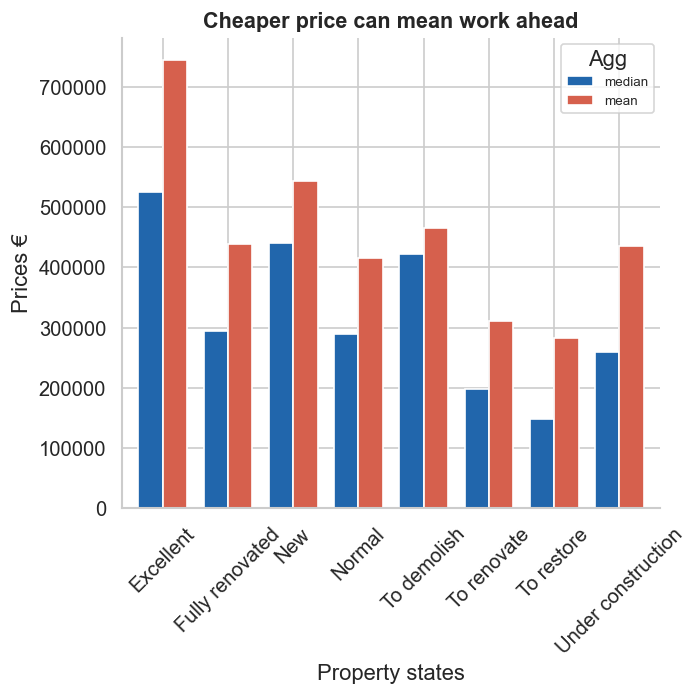

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
property_state[["median", "mean"]].plot(kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.75, rot=45)

ax.set_title('Cheaper price can mean work ahead')
ax.set_ylabel('Prices €')
ax.set_xlabel('Property states')
ax.legend(title='Agg', fontsize=8)
plt.tight_layout()

In [ ]:

print(df.info())
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
print(nan_percentages.loc['property_state'])


In [ ]:
#df['property_state'] = df['property_state'].astype('Int64')
print(df.info())
nan_percentages = (df.isna().mean() * 100).to_frame(name='NaN_Percentage').sort_values(by='NaN_Percentage', ascending=False)
print(nan_percentages.loc['property_state'])

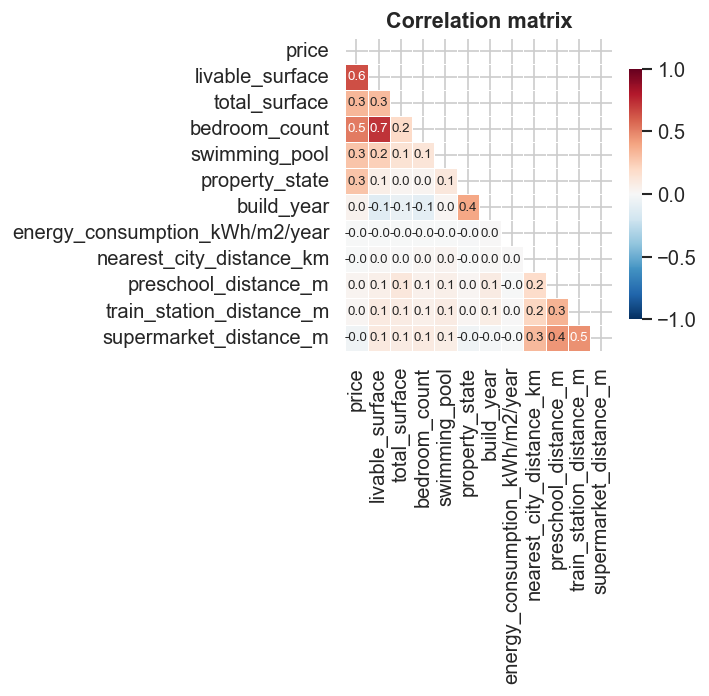

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

corr = numerical.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask,cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix')
plt.tight_layout()

In [20]:
to_demolish = df[df['property_state'] == 'To demolish']
to_demolish.head(8)

,property_type,property_id,postcode,city,province,address,latitude,longitude,price,property_state,...,total_surface,garage,terrace,energy_consumption_kWh/m2/year,swimming_pool,preschool_distance_m,train_station_distance_m,supermarket_distance_m,nearest_city,nearest_city_distance_km
2693,house,RBW24726,9260,Wichelen,east-flanders,Steenakker 8,51.001587,3.966080,199000,To demolish,...,794,0,1,1368,0,1200,248,1200,Ghent,18.35
3308,house,RBV88761,9700,Melden,east-flanders,Rotelenberg 10,50.813013,3.572167,565000,To demolish,...,4289,0,<NA>,<NA>,0,653,5700,3800,Ghent,28.70
3715,house,RBV37987,1670,Pepingen,vlaams-brabant,Molenstraat 1,50.739345,4.136316,299000,To demolish,...,497,1,0,751,0,2700,8200,3000,Brussels,19.18
7948,house,VBE08257,6180,Courcelles,hainaut,rue Nolichamps 45,50.447730,4.373600,20000,To demolish,...,500,0,1,1325,0,956,1900,1400,Charleroi,6.49
9117,house,VBD72056,7542,Mont-Saint-Aubert,hainaut,NaN,50.654828,3.404035,450000,To demolish,...,12533,0,0,<NA>,0,2800,7300,3100,Ghent,49.57
14031,house,VBD44619,1310,La Hulpe,brabant-wallon,NaN,50.730995,4.485671,395000,To demolish,...,570,0,1,861,0,12,1200,588,Brussels,16.02
14537,house,VBD88439,1420,Braine-l&#x27;Alleud,brabant-wallon,NaN,50.696902,4.353838,895000,To demolish,...,2465,0,<NA>,478,0,860,2700,410,Brussels,16.66
14559,house,VBD46531,1420,Braine-l&#x27;Alleud,brabant-wallon,NaN,50.696902,4.353838,895000,To demolish,...,2465,0,<NA>,478,0,860,2700,410,Brussels,16.66


!!!!! one duplicate !!!!
New ideas to delete duplicates : 
if lat, long, price, surface are the same?

&#x27  -> '
looking at strings to collecte characters to parse
&#xE2; -> â
&#xE9; -> é
&#xE8; -> è

In [30]:
strings_col_names = []
for col, serie in df.items():
    if serie.dtype == "str" and 'property' not in col:
        strings_col_names.append(col)
print(strings_col_names)


['city', 'province', 'address', 'nearest_city']


In [33]:
strings_col = df[strings_col_names]
for col in strings_col:
    strings_col[col] = strings_col[col].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
strings_col.to_csv('strings.csv')
# Solved everything !

Going for a scatter plot of price vs distances

/var/folders/km/ghx8xx4s4q77h_htj648vz280000gn/T/ipykernel_71346/3050397905.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


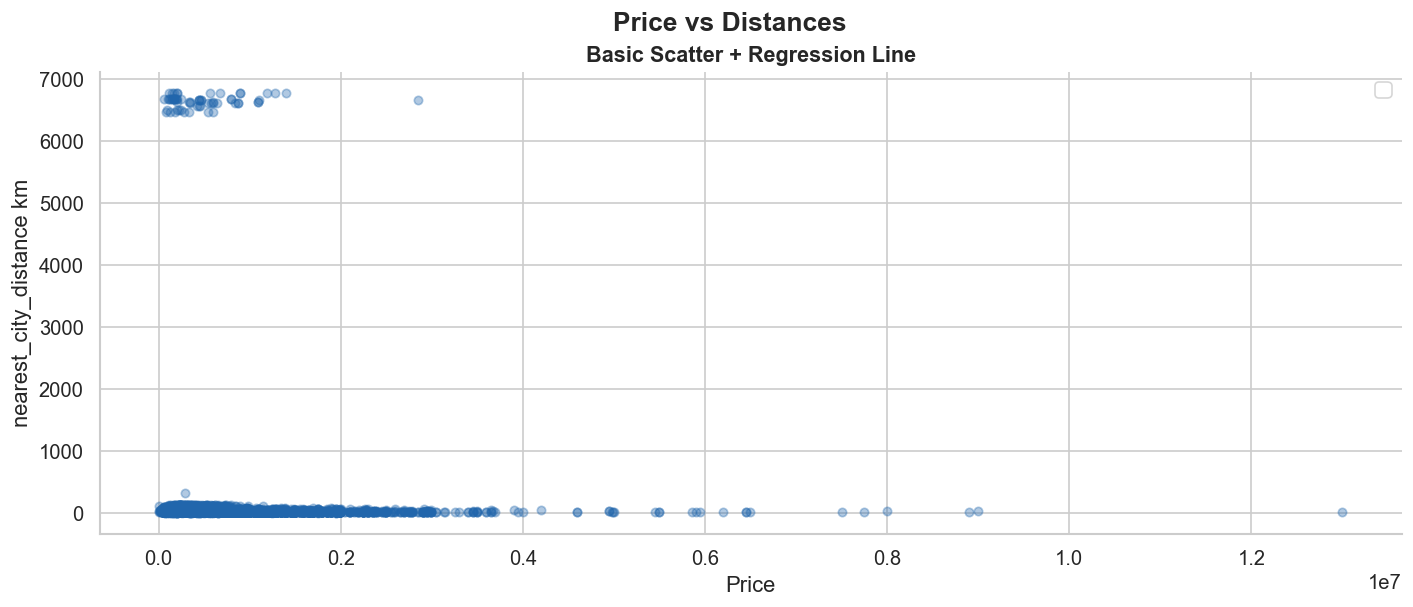

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Price vs Distances', fontweight='bold')

# ── Basic scatter ──────────────────────────────────────────────────────────
ax.scatter(df['price'], df['nearest_city_distance_km'], alpha=0.35, color=BLUE, s=25)
# Add regression line
#m, b = np.polyfit(df['price'], df['nearest_city_distance_km'], 1)
#x_line = np.linspace(df['price'].min(), df['price'].max(), 100)
#ax.plot(x_line, m*x_line + b, color=ORANGE, lw=2.5, label=f'Slope: +€{m:,.0f}/yr')
ax.set_xlabel('Price')
ax.set_ylabel('nearest_city_distance km')
ax.set_title('Basic Scatter + Regression Line')
ax.legend()
#ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x/1000:.0f}k'))

In [55]:
closer = df[df['nearest_city_distance_km'] < 300]
print(closer.shape)
print(closer.info())
further = df[df['nearest_city_distance_km'] >= 300]
print(further.shape)

(14643, 23)
<class 'pandas.DataFrame'>
Index: 14643 entries, 0 to 14707
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   property_type                   14643 non-null  str    
 1   property_id                     14643 non-null  str    
 2   postcode                        14643 non-null  int64  
 3   city                            14643 non-null  str    
 4   province                        14643 non-null  str    
 5   address                         11442 non-null  str    
 6   latitude                        14643 non-null  float64
 7   longitude                       14643 non-null  float64
 8   price                           14643 non-null  int64  
 9   property_state                  11433 non-null  str    
 10  build_year                      9128 non-null   Int64  
 11  bedroom_count                   14253 non-null  Int64  
 12  livable_surface                 1379

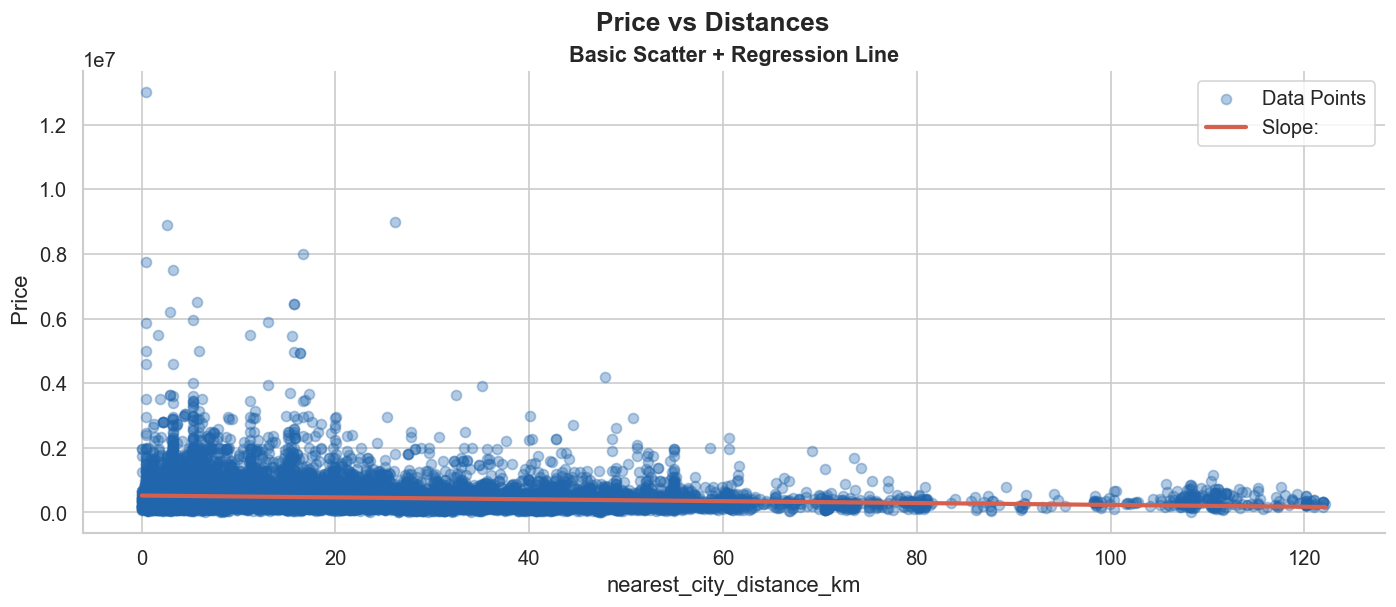

In [67]:
import numpy as np
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Price vs Distances', fontweight='bold')

# ── Basic scatter ──────────────────────────────────────────────────────────
ax.scatter(closer['nearest_city_distance_km'],closer['price'], alpha=0.35, color=BLUE, label='Data Points')
# Add regression line
m, b = np.polyfit(closer['nearest_city_distance_km'],closer['price'],  1)
x_line = np.linspace(closer['nearest_city_distance_km'].min(), closer['nearest_city_distance_km'].max(), 100)
ax.plot(x_line, m*x_line + b, color=ORANGE, lw=2.5, label=f'Slope: ')
ax.set_xlabel('nearest_city_distance_km')
ax.set_ylabel(' Price')
ax.set_title('Basic Scatter + Regression Line')

ax.legend()

plt.show()


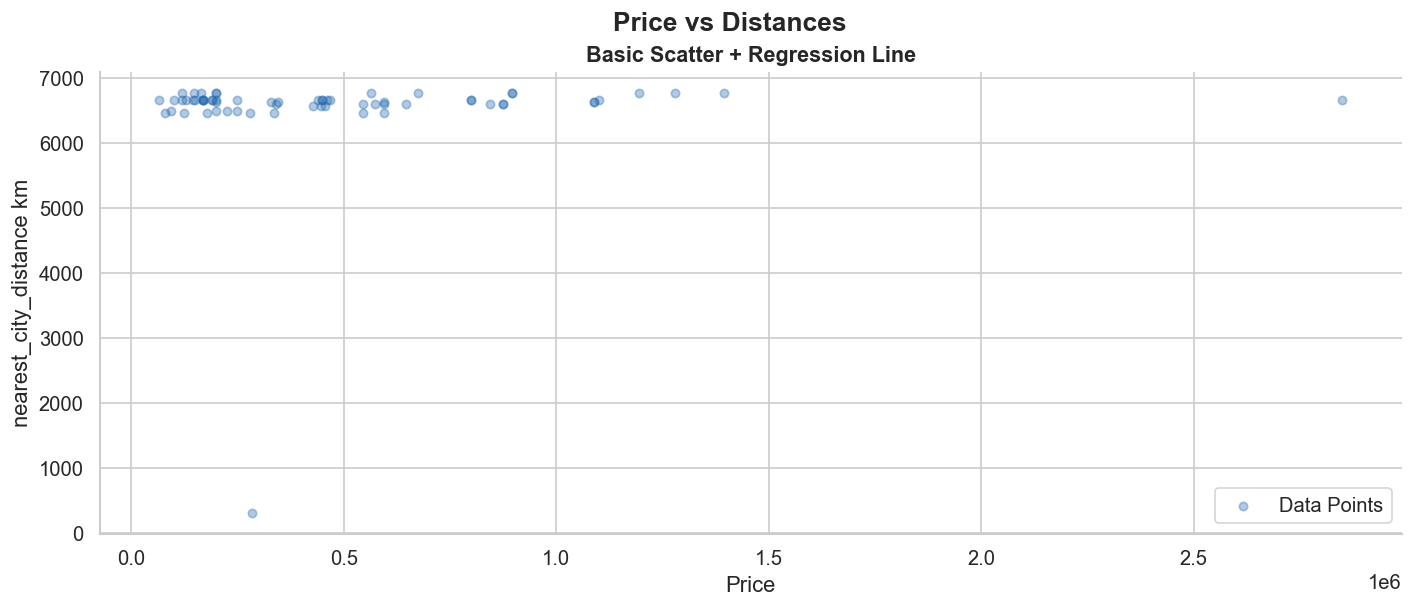

In [57]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Price vs Distances', fontweight='bold')

# ── Basic scatter ──────────────────────────────────────────────────────────
ax.scatter(further['price'], further['nearest_city_distance_km'], alpha=0.35, color=BLUE, s=25, label='Data Points')

ax.set_xlabel('Price')
ax.set_ylabel('nearest_city_distance km')
ax.set_title('Basic Scatter + Regression Line')

ax.legend()

plt.show()

In [58]:
further[['latitude', 'longitude', 'province']].to_csv('further.csv')

!!!! lat and long inverted in further !   + 1 in france lat: 47.5126795; long : 4.635412

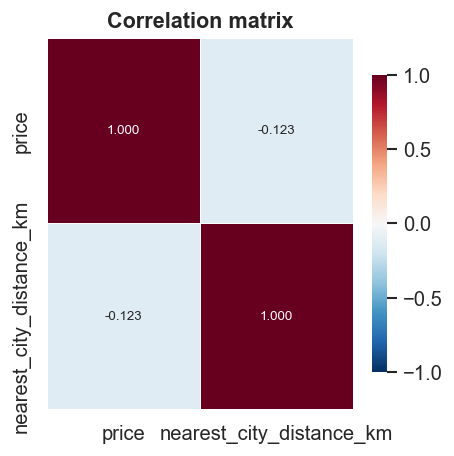

In [68]:
fig, ax = plt.subplots(figsize=(4, 4))

corr = closer[['price', 'nearest_city_distance_km']].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.3f',
            linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix')
plt.tight_layout()

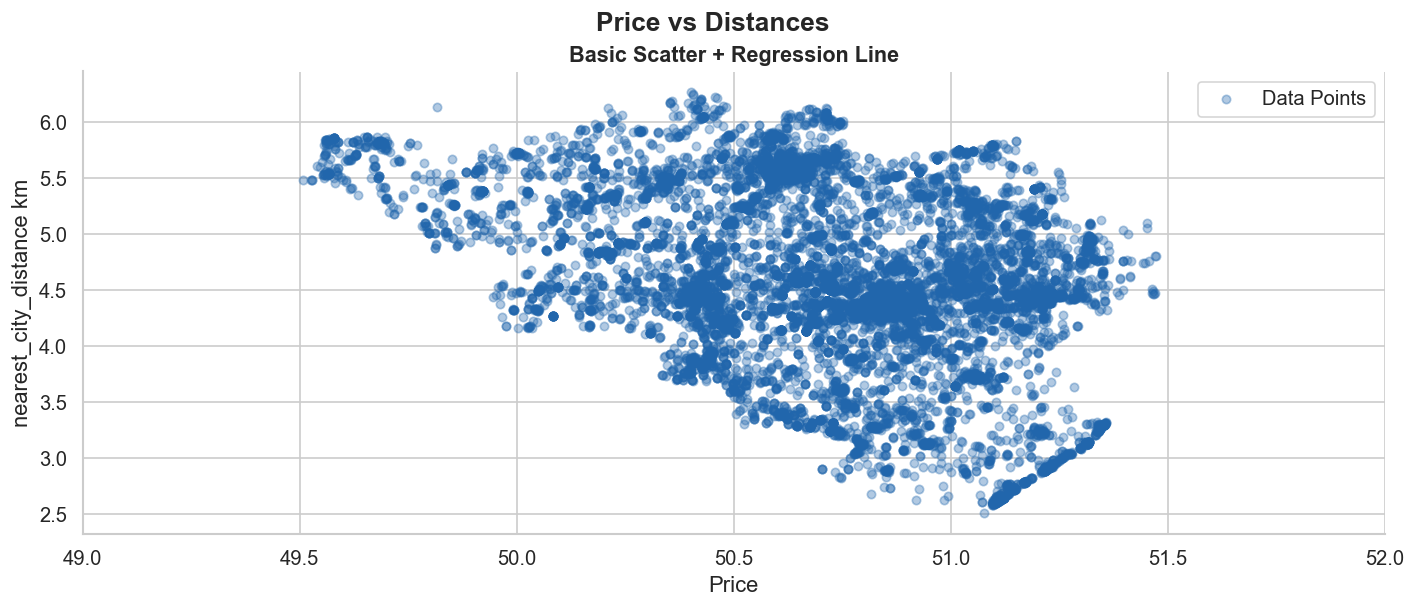

In [71]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Price vs Distances', fontweight='bold')

# ── Basic scatter ──────────────────────────────────────────────────────────
ax.scatter(closer['latitude'], closer['longitude'], alpha=0.35, color=BLUE, s=25, label='Data Points')

ax.set_xlabel('Price')
ax.set_ylabel('nearest_city_distance km')
ax.set_title('Basic Scatter + Regression Line')
#setting ticks
ax.set_xticks(np.arange(49, 52.5, 0.5))

ax.legend()

plt.show()